***

## NLP - PRACTICAL 4 - TEXT CLASSIFICATION (SENTIMENT ANALAYSIS)

***

## aim:

To build a complete text-classification pipeline that preprocesses text, converts it into TF-IDF vectors, trains a Logistic Regression classifier, and evaluates its sentiment predictions.

## problem statement:

Given a labelled text dataset containing sentiment classes, preprocess the text, train a classifier using TF-IDF features, predict the sentiment of unseen text, and evaluate the model using accuracy, precision, recall, F1-score and a confusion matrix.

***

## 1. importing libraries

In [6]:
# Libraries for data handling, preprocessing, vectorization and classification
import pandas as pd
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ( accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)

import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shinde\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 2. data handling

In [7]:
# Generic labelled text dataset
df = pd.DataFrame({
    "text": [
        "I absolutely loved this movie",
        "This was a terrible experience",
        "The movie was okay",
        "Amazing performance and great story",
        "I did not enjoy the service",
        "It was an average experience"
    ],
    "sentiment": [
        "positive",
        "negative",
        "neutral",
        "positive",
        "negative",
        "neutral"
    ]
})

print(df)
print("\nClass distribution:")
print(df["sentiment"].value_counts())

                                  text sentiment
0        I absolutely loved this movie  positive
1       This was a terrible experience  negative
2                   The movie was okay   neutral
3  Amazing performance and great story  positive
4          I did not enjoy the service  negative
5         It was an average experience   neutral

Class distribution:
sentiment
positive    2
negative    2
neutral     2
Name: count, dtype: int64


## 3. preprocessing

In [8]:
# Clean links, mentions, symbols, stopwords and short tokens
stop_words = set(stopwords.words("english"))

def preprocess(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)       # remove links
    text = re.sub(r"@\w+", "", text)          # remove mentions
    text = re.sub(r"[^a-z\s]", " ", text)     # keep letters
    tokens = [
        token
        for token in text.split()
        if token not in stop_words and len(token) > 2
    ]
    return " ".join(tokens)

df["clean"] = df["text"].apply(preprocess)

print(df[["text", "clean"]])

                                  text                            clean
0        I absolutely loved this movie           absolutely loved movie
1       This was a terrible experience              terrible experience
2                   The movie was okay                       movie okay
3  Amazing performance and great story  amazing performance great story
4          I did not enjoy the service                    enjoy service
5         It was an average experience               average experience


## 4. train-test data

In [9]:
# Keep the test data unseen during vectorizer/model training
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( df["clean"], df["sentiment"], test_size=0.5, random_state=42, stratify=df["sentiment"])

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 3
Testing samples: 3


## 5. tf-idf vectorization

In [10]:
# Learn the vocabulary and IDF weights only from training text
vectorizer = TfidfVectorizer(  max_features=5000,  ngram_range=(1, 2))

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Training matrix shape:", X_train_vec.shape)
print("Testing matrix shape:", X_test_vec.shape)

Training matrix shape: (3, 13)
Testing matrix shape: (3, 13)


## 6. build and train the model

In [11]:
# Logistic Regression is a strong and simple baseline for text classification
model = LogisticRegression(max_iter=1000)

model.fit(X_train_vec, y_train)

print("Model training completed.")

Model training completed.


## 7. prediction

In [12]:
# Predict the class of unseen test documents
predictions = model.predict(X_test_vec)

print("Predictions:")
print(predictions)

Predictions:
['negative' 'neutral' 'negative']


## 8. evaluation

In [13]:
# Calculate overall and per-class performance
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", round(accuracy, 3))
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy: 0.333

Classification Report:
              precision    recall  f1-score   support

    negative       0.50      1.00      0.67         1
     neutral       0.00      0.00      0.00         1
    positive       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.17      0.33      0.22         3
weighted avg       0.17      0.33      0.22         3



C:\Users\Shinde\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Shinde\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Shinde\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

## 9. confusion matrix

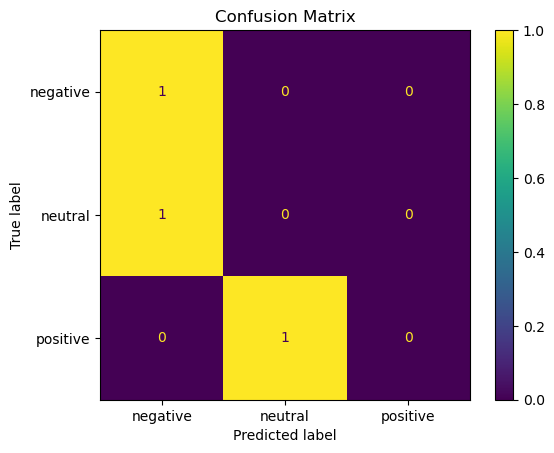

In [14]:
# Show where the classifier is making class-wise errors
cm = confusion_matrix( y_test, predictions, labels=model.classes_)

ConfusionMatrixDisplay( confusion_matrix=cm, display_labels=model.classes_).plot()

plt.title("Confusion Matrix")
plt.show()

## 10. classify new text

In [15]:
# New text must go through the same preprocessing and vectorization
new_text = "The movie was fantastic and enjoyable"

clean_text = preprocess(new_text)

new_vector = vectorizer.transform([clean_text])

prediction = model.predict(new_vector)[0]

print("Text:", new_text)
print("Predicted sentiment:", prediction)

Text: The movie was fantastic and enjoyable
Predicted sentiment: neutral


## 11. important variation — class probabilities

In [16]:
# predict_proba gives the probability assigned to each class
probabilities = model.predict_proba(new_vector)[0]

for label, probability in zip(model.classes_, probabilities):
    print(label, round(probability, 3))

negative 0.283
neutral 0.433
positive 0.283


## 12. important variation — improve the representation

In [17]:
# Bigrams can capture short phrases and some word-order information
vectorizer = TfidfVectorizer( max_features=10000, ngram_range=(1, 2))

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

predictions = model.predict(X_test_vec)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

    negative       0.50      1.00      0.67         1
     neutral       0.00      0.00      0.00         1
    positive       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.17      0.33      0.22         3
weighted avg       0.17      0.33      0.22         3



C:\Users\Shinde\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Shinde\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Shinde\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

***

## output:

The program produces:
- class distribution
- cleaned text
- TF-IDF matrix dimensions
- model predictions
- accuracy and classification report
- confusion matrix
- prediction for a new text
- optional class probabilities

***

## result:

A complete text-classification pipeline was implemented using preprocessing, TF-IDF vectorization, Logistic Regression, prediction and standard classification metrics.

## observation:

The text classification pipeline successfully converts raw text into cleaned text, represents it numerically using TF-IDF, trains a Logistic Regression classifier, and predicts sentiment for unseen text. The confusion matrix and classification report show class-wise performance and errors.

A key implementation detail is that the vectorizer is fitted only on training text and only transformed on test text. Fitting on the test set would expose information from unseen data and cause data leakage.

***

## viva questions:

1. **What is text classification?**  
   Assigning one or more predefined classes to a text document.

2. **Why preprocess text?**  
   To reduce noise and create a consistent representation for modelling.

3. **Why use TF-IDF?**  
   It converts text into numerical features while reducing the importance of terms common across documents.

4. **Why fit the vectorizer only on training data?**  
   To prevent information from the test set entering the learned representation.

5. **What is data leakage?**  
   When information from outside the training data improperly influences model training.

6. **Why use Logistic Regression?**  
   It is a simple, efficient and strong baseline for many text-classification problems.

7. **What does `max_features` do?**  
   Limits the number of vocabulary features.

8. **What does `ngram_range=(1,2)` mean?**  
   Include unigrams and bigrams.

9. **What does `predict()` return?**  
   The predicted class labels.

10. **What does `predict_proba()` return?**  
    The estimated probability for each class.

11. **What is accuracy?**  
    The proportion of total predictions that are correct.

12. **What is precision?**  
    Of the samples predicted as a class, how many actually belong to that class.

13. **What is recall?**  
    Of the samples actually belonging to a class, how many were correctly identified.

14. **What is F1-score?**  
    The harmonic mean of precision and recall.

15. **What is a confusion matrix?**  
    A table showing correct and incorrect predictions for each class.

16. **Why can accuracy be insufficient?**  
    It can hide poor performance on minority classes.

17. **What problem do unigrams have?**  
    They largely ignore word order, so phrases such as `not good` can be difficult to interpret.

18. **Why can bigrams help?**  
    They capture short word sequences such as `not good`.

19. **What happens when a completely unseen word appears in test data?**  
    A fitted TF-IDF vectorizer simply ignores it if it is not in the learned vocabulary.

20. **Can this pipeline be used for tasks other than sentiment?**  
    Yes. The labels can be changed for spam detection, topic classification, support-ticket routing and similar tasks.

***